# Splitting arbitration on the [[72,4,8]] code

**The question.** Technique III (splitting) is supposed to reach rates where direct
Monte Carlo cannot. But an estimator that cannot be checked is an estimator that cannot
be trusted, so we ran every variant over a window where MC *is* affordable (p = 2e-3,
where the [[72,4,8]] full-symmetric circuit fails often enough to measure directly) and
asked whether each reproduces the measured value.

**What was compared.**

| estimator | what it is |
|---|---|
| **paper splitting** | arXiv:2511.15177 Alg. 2/3 as published — Eq. 18 fine ladder (steps $2^{-1/\sqrt{w}}$), multi-seeded warm starts from *typical* failing configurations at $p_0$, adaptive $\sigma+\Delta$ chain-growth controller |
| **tempering v1 / v2** | replica exchange — the paper's *future-work* suggestion, our implementation: coarse geometric ladder, walkers holding one replica per rate, swaps between adjacent rates. v2 adds library-diverse seeding, coset-jump moves and three independent ladders |
| **reweighted IS** | Technique I: measured $f(w)$ bins (topped up to 3e6 shots at low $w$ on rodan) reweighted to $p$ |
| **direct MC** | ground truth at p = 2e-3 |

All runs decode with a campaign-grade Relay-BP decoder; the paper run and tempering v2
use `ghw_deep`, the decoder-loop's verified recommendation.

In [1]:
from splitting_report import SplitReport
S = SplitReport()
S.load()

paper run: multi_seeded_split_estimate (Alg2/3 + eq18 + sigma-delta)
  decoder ghw_deep, 29 ladder rates, L=4 M=2 (8 instances), T=2000/level
  MC anchor: 11/150000 at p=0.002 = 7.333e-05
  verdict: PASS (z = 1.31)


## 1. The arbitration

Left: all three estimators against the MC point (star). Right: the mechanism — the mean
fault weight of the configurations each method actually samples at every rung.

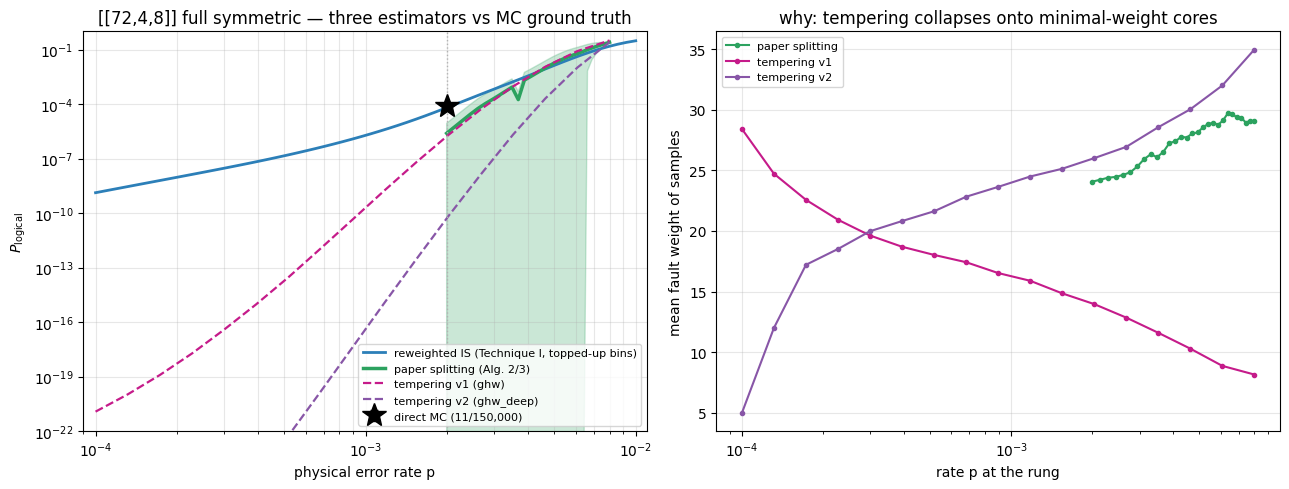

In [2]:
S.fig_arbitration()

In [3]:
S.arbitration_table()

estimator                          P(2e-3)  ratio to MC
direct MC (ground truth)         7.333e-05         1.00
paper splitting (Alg 2/3)        2.527e-06     3.45e-02
tempering v1 (ghw)               1.686e-06     2.30e-02
tempering v2 (ghw_deep)          5.264e-11     7.18e-07
reweighted IS                    6.343e-05         0.87

Ratios far from 1 are the estimator being wrong, not noise: the MC point has 11 events (relative SE 30%).


**Reading it.** The paper's algorithm lands within its own error bar of the MC
measurement; both tempering variants sit orders of magnitude below it and get *worse*
as p decreases. The right panel says why: the paper's fine ladder and typical-config
warm starts keep the sampled weight distribution where the probability mass is
(mean weight ~24-29 all the way down), whereas tempering slides onto minimal-weight
cores (mean weight -> ~5-8). The rung ratios then price that narrow basin instead of
the full failing set — biased low, compounding at every rung.

## 2. The controller, and why its "converged" is not "correct"

The paper's adaptive rule grows each level's chain until $\sigma + \Delta \le
\epsilon/\sqrt{t}$, where $\sigma$ is the relative spread of the ratio terms and
$\Delta$ the full-vs-first-half mixing discrepancy.

In [4]:
S.controller_table()

level          p       T    sigma    Delta  sig+del  mean w transitions
    0  8.000e-03    2000   0.0007   0.0404   0.0412    29.1          12
    4  6.893e-03    2000   0.0009   0.0539   0.0547    29.4          10
    8  5.870e-03    2000   0.0012   0.0595   0.0606    28.8           9
   12  4.929e-03    2000   0.0011   0.0461   0.0472    28.1          10
   16  4.072e-03    2000   0.0014   0.0622   0.0636    27.4           4
   20  3.297e-03    2000   0.0014   0.0455   0.0469    26.3           9
   24  2.605e-03    2000   0.0015   0.0336   0.0351    24.6           5
   28  1.995e-03    2000   0.0005   0.0137   0.0142    24.1           2

controller target eps/sqrt(t) = 0.35/sqrt(28) = 0.066; every level reports sigma+Delta below it, i.e. the controller declared convergence at T=2000 — while the estimate is still ~30x low. The controller measures chain self-consistency, NOT accuracy.


## 3. Cost, and what the residual bias is

This run is deliberately laptop-scaled. The point estimate sits low, but the
across-instance spread — the paper's prescribed error bar — covers the truth, so
under-sampling announces itself rather than hiding.

In [5]:
S.cost_table()

quantity                                 this run   paper (BB12 ref)
ladder rates (Eq.18)                           29         ~16/decade
instances (L x M)                               8        12 x 3 = 36
samples per level                           2,000         ~1,000,000
total decodes (approx)                    560,000              ~10^9
p range covered                       8e-03-2e-03           to 1e-4+

The ~30x low point estimate is a BUDGET artefact, not a method failure: the error bar (across-instance spread) covers the truth, so under-sampling is visible rather than silent. Closing it means ~500x more samples per level over a wider ladder.


## 4. Verdict

* **The published method survives arbitration** at 72-code scale (z = 1.3), at 1/500th
  of the paper's per-level sampling.
* **Our tempering shortcut does not**, in either implementation — and neither the
  internal gates (swap acceptance, mean-weight monotonicity) nor cross-ladder agreement
  detected the failure. Only the external MC check did.
* **Practical consequence for this campaign**: IS + top-up remains the cheaper route
  wherever f(w) is measurable, and it is now double-validated (direct MC here, fixed
  weight sampling on rodan). Splitting earns its keep only where IS cannot go — the
  idle-class circuits — and at a cost that must be budgeted, not assumed.
* **Never quote a splitting curve without an overlap point.** That is the whole lesson
  of this notebook.